### Architecture 
here the FiLM applied to mid stage with the frozen backbone ?

<br>
<br>

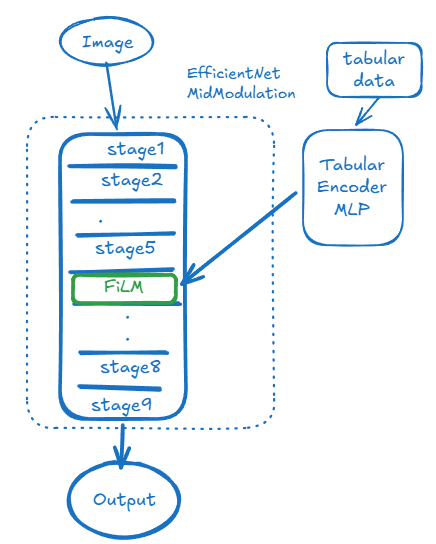



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_BN_fix")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_BN_fix"


TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)
    try:
        best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="film_fusion",   #film_fusion
        tab_cols=tab_cols,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
        ##film related parameter
        film_start_idx=3,                   # to update the backbone block at early stage on index 0 (1st block of EfficientNet)
        apply_to_all_after=False,            # True: apply FiLM toall blocks >= idx, False: only at idx, so here we only apply FiLM at 1st stage/block of EfficientNet
        use_bn_affine=True,                # False => BN used but only normalizes values and doest not apply affine transformation(gamma & beta), instead FiLM applies affine transformation
        freeze_backbone=True,              # False => finetune EfficientNet-B1,True -> Freezen backbone entirely
        BN_running_state_frozen=False
    )
    except Exception as e:
        import traceback
        print(f"\n[ERROR] Fold {fold} crashed")
        traceback.print_exc()
        raise    

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_BN_fix: Fold 1 ===
[TRAIN BATCH 247] preds min=0.6597 max=13.4341 mean=6.4858var=8.5251
[TRAIN BATCH 247] loss=1453.7914
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=40.6437 | ValRMSE: 38.4613
[TRAIN BATCH 247] preds min=3.5783 max=23.6420 mean=14.6852var=29.0142
[TRAIN BATCH 247] loss=1010.3425
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=34.7324 | ValRMSE: 32.9465
[TRAIN BATCH 247] preds min=10.1229 max=34.5558 mean=21.9499var=48.5280
[TRAIN BATCH 247] loss=691.3653
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=29.3202 | ValRMSE: 28.7507
[TRAIN BATCH 247] preds min=11.8369 max=52.6563 mean=26.9649var=123.0891
[TRAIN BATCH 247] loss=1143.8992
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=26.0588 | ValRMSE: 26.3925
[TRAIN BATCH 247] preds min=15.7964 max=70.2922 mean=30.5277var=126.8208
[TRAIN BATCH 247] loss=465.0232
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=24.5415 | ValRMSE: 26.0383
[TRAIN BATCH 247] preds min=16.9643 max=60.5037 mean=31.8926v

In [5]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)
    try:
        best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="film_fusion",   #film_fusion
        tab_cols=tab_cols,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
        ##film related parameter
        film_start_idx=3,                   # to update the backbone block at early stage on index 0 (1st block of EfficientNet)
        apply_to_all_after=False,            # True: apply FiLM toall blocks >= idx, False: only at idx, so here we only apply FiLM at 1st stage/block of EfficientNet
        use_bn_affine=True,                # False => BN used but only normalizes values and doest not apply affine transformation(gamma & beta), instead FiLM applies affine transformation
        freeze_backbone=True,              # False => finetune EfficientNet-B1,True -> Freezen backbone entirely
        BN_running_state_frozen=True
    )
    except Exception as e:
        import traceback
        print(f"\n[ERROR] Fold {fold} crashed")
        traceback.print_exc()
        raise    

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_BN_fix: Fold 1 ===
[TRAIN BATCH 247] preds min=0.7354 max=0.7655 mean=0.7476var=0.0000
[TRAIN BATCH 247] loss=2144.3325
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=1511109565795.9260 | ValRMSE: 1625347194880.0000
[TRAIN BATCH 247] preds min=-48793071616.0000 max=19642428.0000 mean=-1950937088.0000var=95233759835167129600.0000
[TRAIN BATCH 247] loss=95230558057307045888.0000
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=843711519575.3519 | ValRMSE: 1576987000832.0000
[TRAIN BATCH 247] preds min=3.2259 max=13.0163 mean=3.6529var=3.8057
[TRAIN BATCH 247] loss=1310.3928
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=579290374850.2074 | ValRMSE: 1576907177984.0000
[TRAIN BATCH 247] preds min=-7423749632.0000 max=4.9238 mean=-296949984.0000var=2204482193344954368.0000
[TRAIN BATCH 247] loss=2204482193344954368.0000
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=858176338648.0856 | ValRMSE: 1595092762624.0000
[TRAIN BATCH 247] preds min=6.2640 max=6.38

In [6]:

#OOF RMSE: 25.3272
import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 1576907068207.0630 (n=1983)
Fold 2 OOF RMSE: 364755454776386.4375 (n=1983)
Fold 3 OOF RMSE: 3363517139.5313 (n=1982)
Fold 4 OOF RMSE: 85571986.1448 (n=1982)
Fold 5 OOF RMSE: 340352500611.0170 (n=1982)


### Train and Validation RMSE Curve

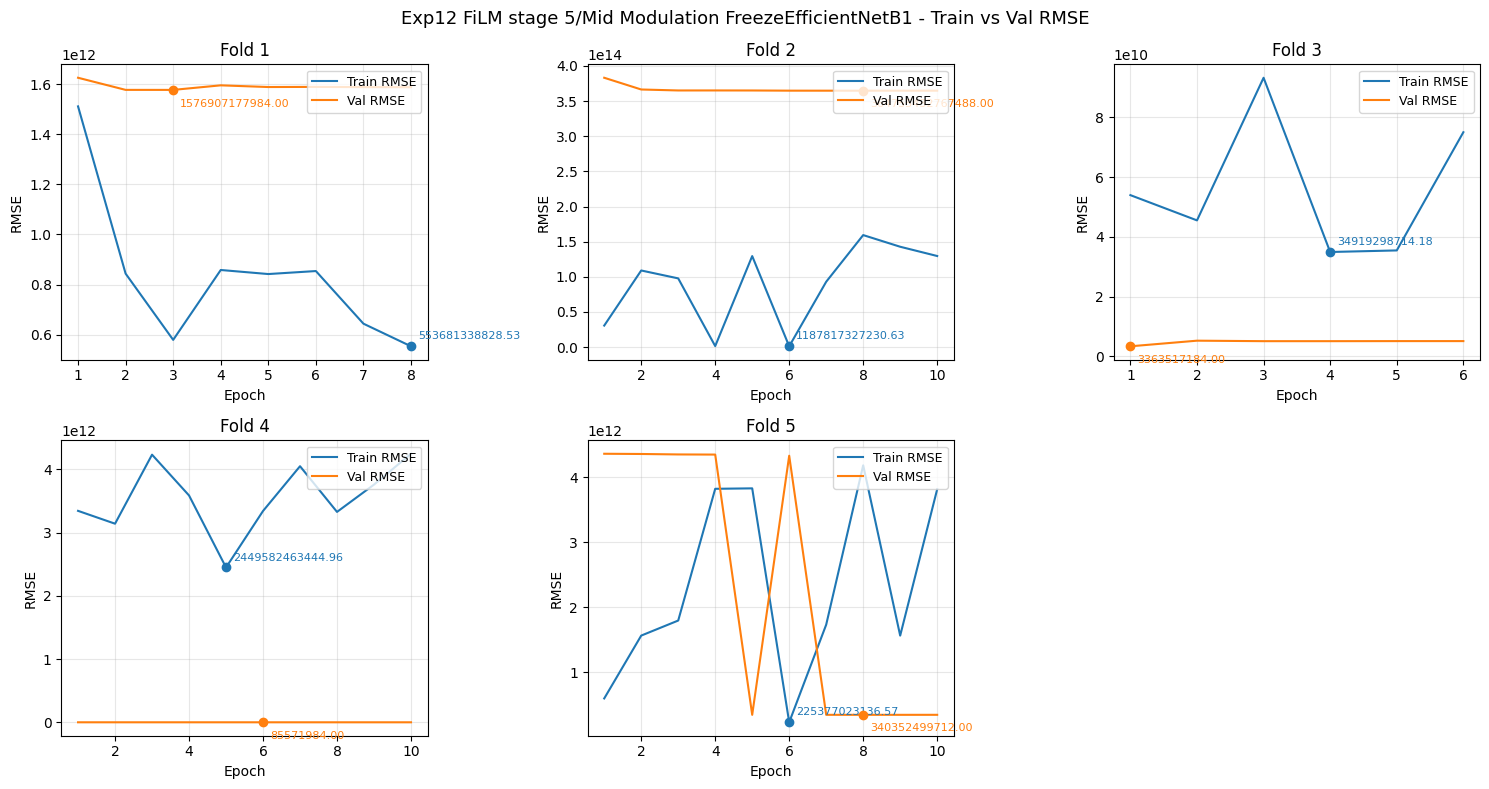

In [7]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM stage 5/Mid Modulation FreezeEfficientNetB1")